In [5]:
# Install & Imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from datetime import datetime

# Style
sns.set_theme(style="whitegrid", font_scale=1.1)
PALETTE = ["#1a6fa8", "#e07b22", "#2ca14b", "#c0392b", "#8e44ad", "#16a085"]
TODAY = pd.Timestamp("2026-05-23")  # anchor date for aging calculations

print("Libraries loaded.")

Libraries loaded.


In [6]:
# Load Data

jira = pd.read_csv("jira.csv")
emp  = pd.read_csv("employee.csv")

print(f"JIRA tickets loaded:   {len(jira):,}")
print(f"Employees loaded:      {len(emp):,}")

JIRA tickets loaded:   6,500
Employees loaded:      10,500


In [7]:
# Date Normalization
# The synthetic dataset contains tickets dated through 2030
# Shift all date columns back 4 years to align with the current date (May 2026)

date_cols = ["Created", "Updated", "Due Date", "Resolution Date"]

# Convert first
for col in date_cols:
    if col in jira.columns:
        jira[col] = pd.to_datetime(jira[col], errors="coerce")

# Calculate exact shift needed
latest_date = jira["Created"].max()
shift_days = (latest_date - TODAY).days
print(f"Latest date in data: {latest_date.date()}")
print(f"Shifting back {shift_days} days ({shift_days/365:.1f} years)")

# Apply exact shift
for col in date_cols:
    if col in jira.columns:
        jira[col] = jira[col] - pd.to_timedelta(shift_days, unit='d')

print("\nCreated range after shift:")
print("  Earliest:", jira["Created"].min().date())
print("  Latest:  ", jira["Created"].max().date())

Latest date in data: 2030-12-22
Shifting back 1674 days (4.6 years)

Created range after shift:
  Earliest: 2010-05-24
  Latest:   2026-05-23


In [8]:
# Bug Taxonomy Classification

#   TIER 1 — Direct Bugs      : explicitly technical defects
#   TIER 2 — Customer Problems: customer-reported issues / complaints
#   TIER 3 — Adjacent Issues  : operational/process problems that cause bugs
#   TIER 4 — Non-Bug Work     : epics, tasks, requests — excluded from bug KPIs

TAXONOMY = {
    # TIER 1 — Direct Bugs
    "bug":              "Tier 1 - Direct Bug",
    "little issue":     "Tier 1 - Direct Bug",
    "big issue":        "Tier 1 - Direct Bug",
    "spot correction":  "Tier 1 - Direct Bug",

    # TIER 2 — Customer-Reported Problems
    "customer complaint": "Tier 2 - Customer Problem",
    "reported issue":     "Tier 2 - Customer Problem",
    "issue":              "Tier 2 - Customer Problem",
    "problem":            "Tier 2 - Customer Problem",

    # TIER 3 — Adjacent / Operational Issues
    "question":        "Tier 3 - Adjacent Issue",
    "work item":       "Tier 3 - Adjacent Issue",
    "change request":  "Tier 3 - Adjacent Issue",

    # TIER 4 — Non-Bug Work (excluded from bug KPIs)
    "epic":        "Tier 4 - Non-Bug Work",
    "initiative":  "Tier 4 - Non-Bug Work",
    "task":        "Tier 4 - Non-Bug Work",
    "work task":   "Tier 4 - Non-Bug Work",
    "request":     "Tier 4 - Non-Bug Work",
    "sub task":    "Tier 4 - Non-Bug Work",
}

jira["issue_type_clean"] = jira["Issue Type"].str.strip().str.lower()
jira["bug_tier"] = jira["issue_type_clean"].map(TAXONOMY).fillna("Tier 4 - Non-Bug Work")

tier_counts = jira["bug_tier"].value_counts()
print("Ticket counts by Bug Tier:\n")
print(tier_counts.to_string())

Ticket counts by Bug Tier:

bug_tier
Tier 4 - Non-Bug Work        2275
Tier 1 - Direct Bug          1573
Tier 2 - Customer Problem    1530
Tier 3 - Adjacent Issue      1122


In [9]:
# Open vs. Resolved Flag & Ticket Aging

OPEN_STATUSES = {"In Progress", "Blocked", "To Do", "Backlog", "In Review"}

jira["is_open"]    = jira["Status"].isin(OPEN_STATUSES)
jira["Created"]    = pd.to_datetime(jira["Created"],    errors="coerce")
jira["Updated"]    = pd.to_datetime(jira["Updated"],    errors="coerce")
jira["Due Date"]   = pd.to_datetime(jira["Due Date"],   errors="coerce")
jira["Resolution Date"] = pd.to_datetime(jira["Resolution Date"], errors="coerce")

jira["age_days"] = (TODAY - jira["Created"]).dt.days

# Aging bucket — used in multiple charts
def age_bucket(d):
    if pd.isna(d):   return "Unknown"
    if d < 30:       return "< 30 days"
    if d < 90:       return "30–90 days"
    if d < 365:      return "90–365 days"
    if d < 730:      return "1–2 years"
    return "2+ years"

jira["age_bucket"] = jira["age_days"].apply(age_bucket)

AGE_ORDER = ["< 30 days", "30–90 days", "90–365 days", "1–2 years", "2+ years"]

open_jira = jira[jira["is_open"]].copy()
bug_jira  = jira[jira["bug_tier"].isin(["Tier 1 - Direct Bug",
                                         "Tier 2 - Customer Problem",
                                         "Tier 3 - Adjacent Issue"])].copy()
open_bugs = open_jira[open_jira["bug_tier"] != "Tier 4 - Non-Bug Work"].copy()

print(f"\nTotal tickets:          {len(jira):,}")
print(f"Open / unresolved:      {open_jira['is_open'].sum():,}  ({open_jira['is_open'].sum()/len(jira)*100:.1f}%)")
print(f"Bug-tier tickets:       {len(bug_jira):,}")
print(f"Open bug-tier tickets:  {len(open_bugs):,}")
print(f"\nOldest open ticket age: {open_jira['age_days'].max():,} days  ({open_jira['age_days'].max()/365:.1f} years)")
print(f"Avg open ticket age:    {open_jira['age_days'].mean():.0f} days")


Total tickets:          6,500
Open / unresolved:      2,809  (43.2%)
Bug-tier tickets:       4,225
Open bug-tier tickets:  1,820

Oldest open ticket age: 5,836 days  (16.0 years)
Avg open ticket age:    2137 days


In [10]:
# Employee Hierarchy (Self-Join)

emp["full_name"] = emp["first_name"] + " " + emp["last_name"]

# Level → org tier
LEVEL_TIER = {
    "Z": "C-Suite (CEO)",           "Y": "C-Suite (President)",
    "X": "C-Suite (EVP)",           "W": "C-Suite (CxO/SVP)",
    "V": "VP",                      "U": "VP/Sr Director",
    "T": "Director II",             "S": "Director I",
    "R": "Sr Manager",              "Q": "Manager II",
    "P": "Manager I",               "O": "Sr Staff Engineer",
    "N": "Staff Engineer II",       "M": "Staff Engineer I",
    "L": "Sr Engineer",             "K": "Eng Manager I",
    "J": "Eng Manager II",          "I": "Sr Software Engineer",
    "H": "Software Engineer II",    "G": "Software Engineer I",
    "F": "Assoc Software Engineer", "E": "Analyst II",
    "D": "Analyst II",              "C": "Analyst I",
    "B": "Junior Analyst",          "A": "Intern",
}

emp["org_tier"] = emp["level"].map(LEVEL_TIER)

# Self-join: get manager's name, title, level for every employee
mgr_cols = emp[["employee_id", "full_name", "job_title", "level", "org_tier"]].copy()
mgr_cols.columns = ["manager_id", "manager_name", "manager_title",
                    "manager_level", "manager_org_tier"]

emp_full = emp.merge(mgr_cols, on="manager_id", how="left")
emp_full["full_name"] = emp_full["first_name"] + " " + emp_full["last_name"]

print(f"Employees with manager matched: {emp_full['manager_name'].notna().sum():,} of {len(emp_full):,}")
print("\nSample hierarchy:")
print(emp_full[["full_name", "job_title", "level",
                "manager_name", "manager_title", "manager_level"]]
      .dropna(subset=["manager_name"])
      .head(6)
      .to_string(index=False))

Employees with manager matched: 10,481 of 10,500

Sample hierarchy:
    full_name             job_title level   manager_name           manager_title manager_level
     Alex Lee  Software Engineer II     G     Owen Clark         SVP, Technology             S
   Jordan Kim   Software Engineer I     F Liam Rodriguez                     CTO             U
   Sam Garcia Engineering Manager I     K   Sophia Scott         EVP, Technology             X
 Taylor Patel   Software Engineer I     F Charlotte King   President, Technology             Y
  Casey Evans  Software Engineer II     G Charlotte King   President, Technology             Y
Taylor Carter             Analyst I     C     Elijah Lee Chief Executive Officer             Z


In [11]:
# Join JIRA Tickets to Employee Hierarchy

# Match on Assignee full name → employee record → manager chain
assignee_lookup = emp_full[["full_name", "job_title", "level", "org_tier",
                            "manager_name", "manager_title",
                            "manager_level", "manager_org_tier",
                            "cost_center_name", "active"]].copy()
assignee_lookup.columns = [
    "Assignee", "assignee_title", "assignee_level", "assignee_org_tier",
    "assignee_manager", "assignee_manager_title",
    "assignee_manager_level", "assignee_manager_org_tier",
    "assignee_cost_center", "assignee_active"
]

jira_enriched = jira.merge(assignee_lookup, on="Assignee", how="left")

matched = jira_enriched["assignee_title"].notna().sum()
print(f"JIRA tickets matched to employee records: {matched:,} of {len(jira_enriched):,}  "
      f"({matched/len(jira_enriched)*100:.1f}%)")

# Re-derive open subsets with enrichment
open_enriched     = jira_enriched[jira_enriched["is_open"]].copy()
open_bugs_enriched = open_enriched[open_enriched["bug_tier"] != "Tier 4 - Non-Bug Work"].copy()

JIRA tickets matched to employee records: 23,455 of 24,548  (95.5%)


In [12]:
# Drop duplicates introduced by the employee name join
# Keep first match per Issue Key
jira_enriched = jira_enriched.drop_duplicates(subset=["Issue Key"], keep="first")

# Rebuild all downstream subsets cleanly
open_enriched      = jira_enriched[jira_enriched["is_open"]].copy()

open_bugs_enriched = open_enriched[open_enriched["bug_tier"] != "Tier 4 - Non-Bug Work"].copy()
bug_jira           = jira_enriched[jira_enriched["bug_tier"].isin([
                         "Tier 1 - Direct Bug",
                         "Tier 2 - Customer Problem",
                         "Tier 3 - Adjacent Issue"])].copy()

print("jira_enriched rows:", len(jira_enriched))
print("open_enriched rows:", len(open_enriched))
print("open_bugs_enriched rows:", len(open_bugs_enriched))
print("Dupes remaining:", open_bugs_enriched["Issue Key"].duplicated().sum())

jira_enriched rows: 6500
open_enriched rows: 2809
open_bugs_enriched rows: 1820
Dupes remaining: 0


In [13]:
# ROI / Remediation Cost Estimate

HOURLY_RATE = 125

open_bugs_enriched = open_bugs_enriched.copy()

# All 1,820 tickets have Remaining Estimate
open_bugs_enriched["est_cost_best"] = (
    open_bugs_enriched["Remaining Estimate (h)"] * HOURLY_RATE
)

total_cost  = open_bugs_enriched["est_cost_best"].sum()
total_hours = open_bugs_enriched["Remaining Estimate (h)"].sum()

print(f"━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")
print(f"  OPEN BUG-TIER REMEDIATION ESTIMATE")
print(f"━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")
print(f"  Open bug-tier tickets:  {len(open_bugs_enriched):,}")
print(f"  Total remaining hours:  {total_hours:,.0f} hrs")
print(f"  Est. total cost:        ${total_cost:,.0f}")
print(f"  Assumed hourly rate:    ${HOURLY_RATE}/hr")
print(f"  Data source:            Remaining Estimate (h) — 100% coverage")
print(f"━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")

# Sensitivity on hourly rate
print(f"\n  RATE SENSITIVITY (same hours, different rate assumptions)")
print(f"━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")
for label, rate in [("Junior ($75/hr)", 75), ("Mid-level ($125/hr)", 125), ("Senior ($175/hr)", 175)]:
    print(f"  {label:<25}  ${total_hours * rate:>12,.0f}")
print(f"━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")

# Cost by Bug Tier
cost_by_tier = (open_bugs_enriched
                .groupby("bug_tier")["est_cost_best"]
                .sum()
                .sort_values(ascending=False))
print("\nCost by Bug Tier:")
for tier, cost in cost_by_tier.items():
    print(f"  {tier:<35} ${cost:>12,.0f}")

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  OPEN BUG-TIER REMEDIATION ESTIMATE
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Open bug-tier tickets:  1,820
  Total remaining hours:  18,700 hrs
  Est. total cost:        $2,337,500
  Assumed hourly rate:    $125/hr
  Data source:            Remaining Estimate (h) — 100% coverage
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  RATE SENSITIVITY (same hours, different rate assumptions)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Junior ($75/hr)            $   1,402,500
  Mid-level ($125/hr)        $   2,337,500
  Senior ($175/hr)           $   3,272,500
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Cost by Bug Tier:
  Tier 1 - Direct Bug                 $   1,042,375
  Tier 3 - Adjacent Issue             $     710,625
  Tier 2 - Customer Problem           $     584,500


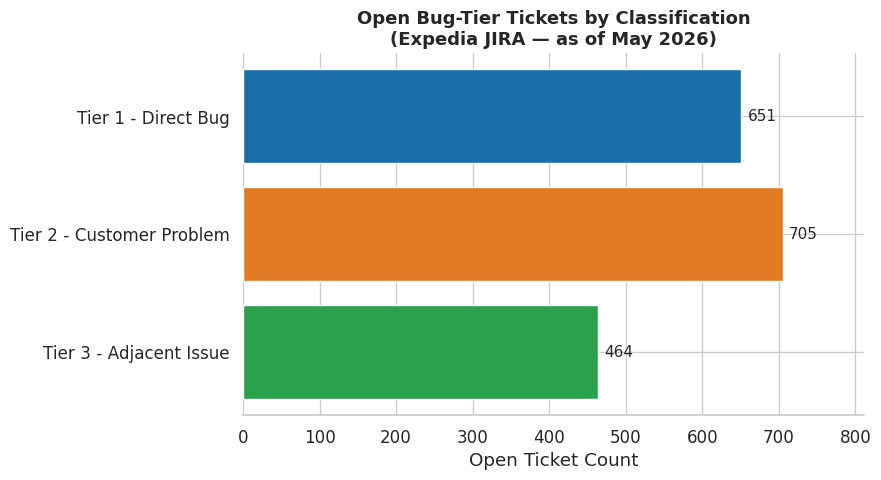

Saved: chart1_tier_counts.png


In [14]:
# CHART 1: Open Tickets by Bug Tier (Bar)

fig, ax = plt.subplots(figsize=(9, 5))
tier_open = (open_bugs_enriched["bug_tier"]
              .value_counts()
             .reindex(["Tier 1 - Direct Bug",
                       "Tier 2 - Customer Problem",
                       "Tier 3 - Adjacent Issue"])
             .fillna(0))

bars = ax.barh(tier_open.index, tier_open.values, color=PALETTE[:3], edgecolor="white")
for bar in bars:
    ax.text(bar.get_width() + 8, bar.get_y() + bar.get_height()/2,
            f"{int(bar.get_width()):,}", va="center", fontsize=11)

ax.set_xlabel("Open Ticket Count")
ax.set_title("Open Bug-Tier Tickets by Classification\n(Expedia JIRA — as of May 2026)",
             fontsize=13, fontweight="bold")
ax.set_xlim(0, tier_open.max() * 1.15)
ax.invert_yaxis()
sns.despine(left=True)
plt.tight_layout()
plt.savefig("chart1_tier_counts.png", dpi=150)
plt.show()
print("Saved: chart1_tier_counts.png")

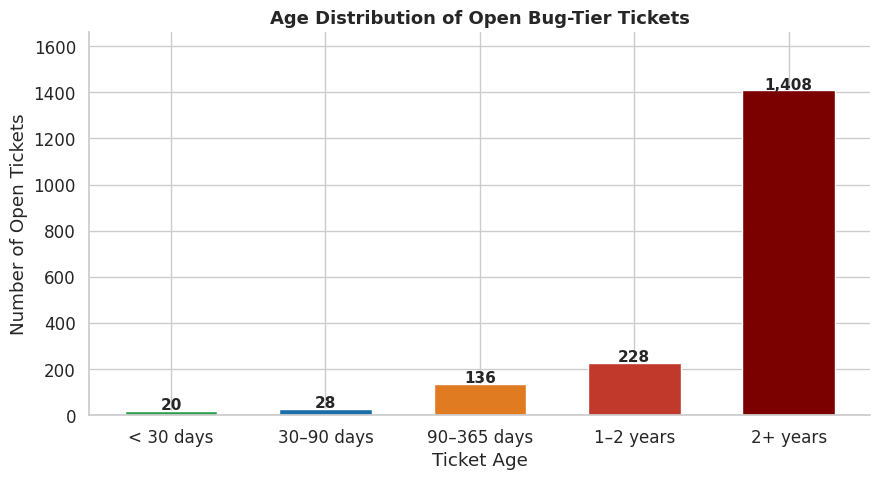

Saved: chart2_aging.png


In [15]:
# CHART 2: Ticket Aging Distribution (open bugs only)

age_dist = (open_bugs_enriched["age_bucket"]
            .value_counts()
            .reindex(AGE_ORDER)
            .fillna(0))

fig, ax = plt.subplots(figsize=(9, 5))
colors_age = ["#2ca14b", "#1a6fa8", "#e07b22", "#c0392b", "#7b0000"]
bars = ax.bar(age_dist.index, age_dist.values, color=colors_age, edgecolor="white", width=0.6)

for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            f"{int(bar.get_height()):,}", ha="center", fontsize=11, fontweight="bold")

ax.set_ylabel("Number of Open Tickets")
ax.set_xlabel("Ticket Age")
ax.set_title("Age Distribution of Open Bug-Tier Tickets",
             fontsize=13, fontweight="bold")
ax.set_ylim(0, age_dist.max() * 1.18)
sns.despine()
plt.tight_layout()
plt.savefig("chart2_aging.png", dpi=150)
plt.show()
print("Saved: chart2_aging.png")

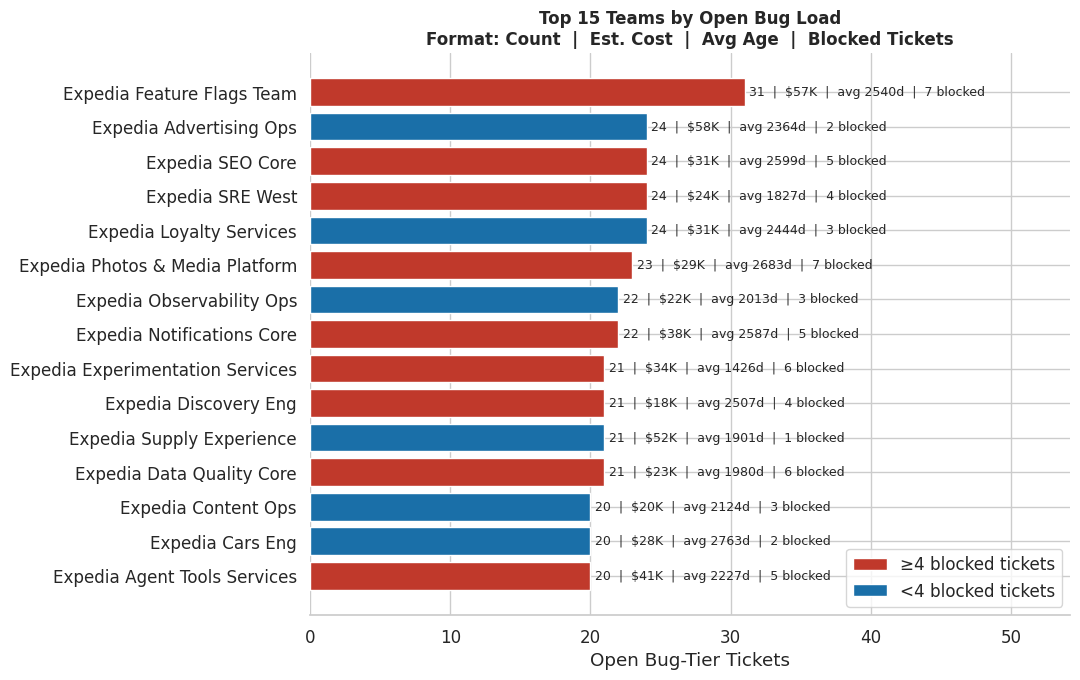

Saved: chart3_team_accountability.png


In [16]:
# CHART 3: Top 15 Teams by Open Bug Count (Accountability Heat Map)

team_open = (open_bugs_enriched
             .groupby("Working Team")
             .agg(
                 open_count=("Issue Key", "count"),
                 est_cost=("est_cost_best", "sum"),
                 avg_age_days=("age_days", "mean"),
                 blocked_count=("Status", lambda x: (x == "Blocked").sum())
             )
             .sort_values("open_count", ascending=False)
             .head(15)
             .reset_index())

fig, ax = plt.subplots(figsize=(11, 7))
bar_colors = [PALETTE[3] if b > 3 else PALETTE[0]
              for b in team_open["blocked_count"]]

bars = ax.barh(team_open["Working Team"], team_open["open_count"],
               color=bar_colors, edgecolor="white")

for i, (bar, row) in enumerate(zip(bars, team_open.itertuples())):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f"{int(bar.get_width())}  |  ${row.est_cost/1000:.0f}K  |  "
            f"avg {row.avg_age_days:.0f}d  |  {row.blocked_count} blocked",
            va="center", fontsize=9)

ax.set_xlabel("Open Bug-Tier Tickets")
ax.set_title("Top 15 Teams by Open Bug Load\n"
             "Format: Count  |  Est. Cost  |  Avg Age  |  Blocked Tickets",
             fontsize=12, fontweight="bold")
ax.set_xlim(0, team_open["open_count"].max() * 1.75)
ax.invert_yaxis()

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=PALETTE[3], label="≥4 blocked tickets"),
    Patch(facecolor=PALETTE[0], label="<4 blocked tickets")
]
ax.legend(handles=legend_elements, loc="lower right")
sns.despine(left=True)
plt.tight_layout()
plt.savefig("chart3_team_accountability.png", dpi=150)
plt.show()
print("Saved: chart3_team_accountability.png")

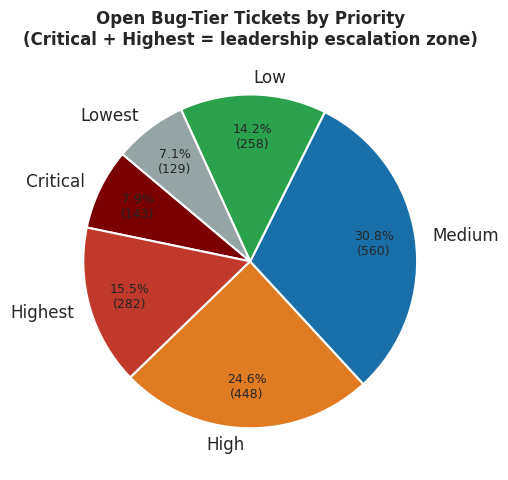

Saved: chart4_priority.png


In [17]:
# CHART 4: Priority Breakdown of Open Bugs

PRIORITY_ORDER = ["Critical", "Highest", "High", "Medium", "Low", "Lowest"]
PRIORITY_COLORS = ["#7b0000", "#c0392b", "#e07b22", "#1a6fa8", "#2ca14b", "#95a5a6"]

priority_counts = (open_bugs_enriched["Priority"]
                   .value_counts()
                   .reindex(PRIORITY_ORDER)
                   .fillna(0))

fig, ax = plt.subplots(figsize=(8, 5))
wedges, texts, autotexts = ax.pie(
    priority_counts.values,
    labels=priority_counts.index,
    colors=PRIORITY_COLORS,
    autopct=lambda p: f"{p:.1f}%\n({int(p*sum(priority_counts.values)/100):,})",
    startangle=140,
    pctdistance=0.75,
    wedgeprops={"edgecolor": "white", "linewidth": 1.5}
)
for at in autotexts:
    at.set_fontsize(9)

ax.set_title("Open Bug-Tier Tickets by Priority\n(Critical + Highest = leadership escalation zone)",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("chart4_priority.png", dpi=150)
plt.show()
print("Saved: chart4_priority.png")

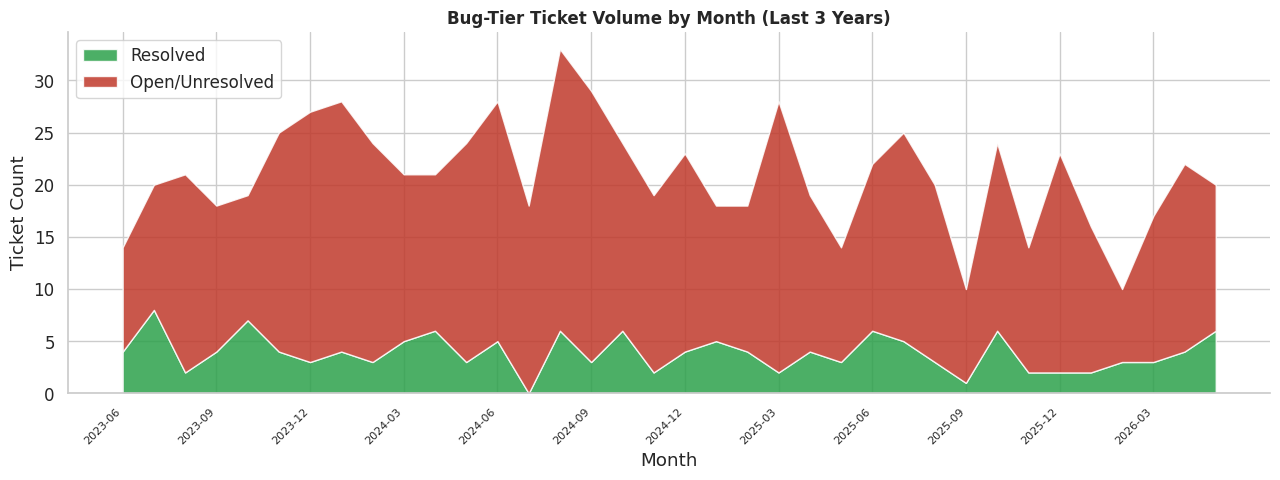

Saved: chart5_monthly_trend.png


In [18]:
# CHART 5: Monthly Ticket Creation Trend (Bug-tier only)

bug_jira_dated = bug_jira.dropna(subset=["Created"]).copy()
bug_jira_dated["month"] = bug_jira_dated["Created"].dt.to_period("M")

monthly = (bug_jira_dated
           .groupby(["month", "is_open"])
           .size()
           .unstack(fill_value=0)
           .rename(columns={True: "Open/Unresolved", False: "Resolved"})
           .tail(36))   # last 3 years

monthly.index = monthly.index.astype(str)

fig, ax = plt.subplots(figsize=(13, 5))
ax.stackplot(monthly.index,
             monthly.get("Resolved", 0),
             monthly.get("Open/Unresolved", 0),
             labels=["Resolved", "Open/Unresolved"],
             colors=[PALETTE[2], PALETTE[3]],
             alpha=0.85)

ax.set_title("Bug-Tier Ticket Volume by Month (Last 3 Years)",
             fontsize=12, fontweight="bold")
ax.set_ylabel("Ticket Count")
ax.set_xlabel("Month")
tick_step = max(1, len(monthly) // 12)
ax.set_xticks(range(0, len(monthly), tick_step))
ax.set_xticklabels(monthly.index[::tick_step], rotation=45, ha="right", fontsize=8)
ax.legend(loc="upper left")
sns.despine()
plt.tight_layout()
plt.savefig("chart5_monthly_trend.png", dpi=150)
plt.show()
print("Saved: chart5_monthly_trend.png")

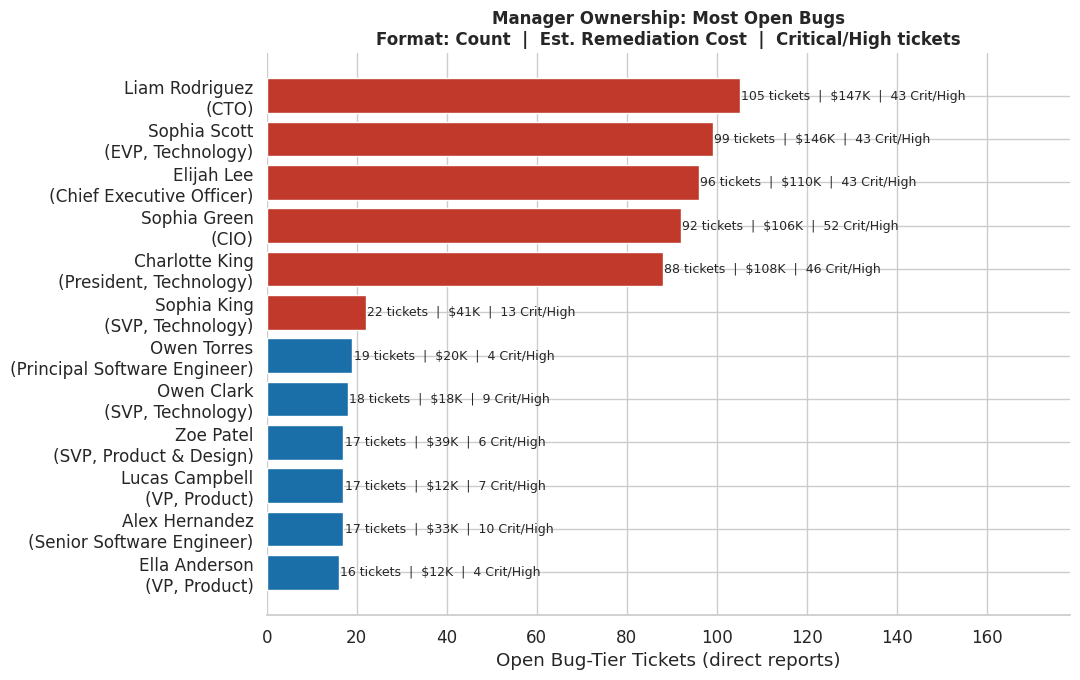

Saved: chart6_manager_accountability.png


In [19]:
# CHART 6: Manager Accountability (VP-level owners of open bugs)

mgr_summary = (open_bugs_enriched
               .dropna(subset=["assignee_manager"])
               .groupby(["assignee_manager", "assignee_manager_title"])
               .agg(
                   open_count=("Issue Key", "count"),
                   est_cost=("est_cost_best", "sum"),
                   critical_high=("Priority",
                                  lambda x: x.isin(["Critical","Highest","High"]).sum())
               )
               .sort_values("open_count", ascending=False)
               .head(12)
               .reset_index())

fig, ax = plt.subplots(figsize=(11, 7))
bar_colors_mgr = [PALETTE[3] if ch > 10 else PALETTE[0]
                  for ch in mgr_summary["critical_high"]]

bars = ax.barh(
    mgr_summary["assignee_manager"] + "\n(" + mgr_summary["assignee_manager_title"] + ")",
    mgr_summary["open_count"],
    color=bar_colors_mgr, edgecolor="white"
)

for bar, row in zip(bars, mgr_summary.itertuples()):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f"{int(bar.get_width())} tickets  |  ${row.est_cost/1000:.0f}K  |  "
            f"{row.critical_high} Crit/High",
            va="center", fontsize=9)

ax.set_xlabel("Open Bug-Tier Tickets (direct reports)")
ax.set_title("Manager Ownership: Most Open Bugs\n"
"Format: Count  |  Est. Remediation Cost  |  Critical/High tickets",
             fontsize=12, fontweight="bold")
ax.set_xlim(0, mgr_summary["open_count"].max() * 1.7)
ax.invert_yaxis()
sns.despine(left=True)
plt.tight_layout()
plt.savefig("chart6_manager_accountability.png", dpi=150)
plt.show()
print("Saved: chart6_manager_accountability.png")

In [20]:
# Export Clean CSVs for Tableau

# Export 1: Full enriched JIRA dataset
jira_enriched.to_csv("jira_enriched.csv", index=False)
print("Exported: jira_enriched.csv")

# Export 2: Open bug-tier tickets with cost estimates (main Tableau source)
open_bugs_enriched.to_csv("open_bugs_with_cost.csv", index=False)
print("Exported: open_bugs_with_cost.csv")

# Export 3: Team summary (for team-level views in Tableau)
team_summary = (open_bugs_enriched
                .groupby("Working Team")
                .agg(
                    open_count=("Issue Key", "count"),
                    est_cost=("est_cost_best", "sum"),
                    avg_age_days=("age_days", "mean"),
                    blocked_count=("Status", lambda x: (x == "Blocked").sum()),
                    critical_high_count=("Priority",
                                         lambda x: x.isin(["Critical","Highest","High"]).sum()),
                    tier1_count=("bug_tier",
                                 lambda x: (x == "Tier 1 - Direct Bug").sum()),
                    tier2_count=("bug_tier",
                                 lambda x: (x == "Tier 2 - Customer Problem").sum()),
                )
                .reset_index()
                .sort_values("open_count", ascending=False))
team_summary.to_csv("team_summary.csv", index=False)
print("Exported: team_summary.csv")

# Export 4: Manager accountability summary
mgr_full_summary = (open_bugs_enriched
                    .dropna(subset=["assignee_manager"])
                    .groupby(["assignee_manager", "assignee_manager_title",
                              "assignee_manager_level", "assignee_manager_org_tier"])
                    .agg(
                        open_count=("Issue Key", "count"),
                        est_cost=("est_cost_best", "sum"),
                        avg_age_days=("age_days", "mean"),
                        blocked_count=("Status", lambda x: (x == "Blocked").sum()),
                        critical_high_count=("Priority",
                                             lambda x: x.isin(["Critical","Highest","High"]).sum())
                    )
                    .reset_index()
                    .sort_values("open_count", ascending=False))
mgr_full_summary.to_csv("manager_accountability.csv", index=False)
print("Exported: manager_accountability.csv")

# Export 5: Employee hierarchy (for Tableau org-level filtering)
emp_hierarchy = emp_full[["employee_id", "full_name", "job_title", "level", "org_tier",
                          "cost_center_name", "active", "country", "timezone",
                          "manager_id", "manager_name", "manager_title",
                           "manager_level", "manager_org_tier"]].copy()
emp_hierarchy.to_csv("employee_hierarchy.csv", index=False)
print("Exported: employee_hierarchy.csv")

print("\nAll 5 CSVs ready")

Exported: jira_enriched.csv
Exported: open_bugs_with_cost.csv
Exported: team_summary.csv
Exported: manager_accountability.csv
Exported: employee_hierarchy.csv

All 5 CSVs ready


In [21]:
# Executive Summary Stats

total_tickets      = len(jira)
open_tickets       = jira["is_open"].sum()
open_bug_tier      = len(open_bugs_enriched)
pct_open           = open_tickets / total_tickets * 100
oldest_days        = int(open_bugs_enriched["age_days"].max())
oldest_years       = oldest_days / 365
blocked_tickets    = (open_bugs_enriched["Status"] == "Blocked").sum()
critical_open      = open_bugs_enriched["Priority"].isin(["Critical","Highest"]).sum()
top_team           = team_summary.iloc[0]["Working Team"]
top_team_count     = int(team_summary.iloc[0]["open_count"])
total_rem_cost     = open_bugs_enriched["est_cost_best"].sum()

print("=" * 52)
print("  EXECUTIVE SUMMARY — KEY NUMBERS")
print("=" * 52)
print(f"  Total JIRA tickets:               {total_tickets:,}")
print(f"  Open / unresolved:                {open_tickets:,}  ({pct_open:.1f}%)")
print(f"  Open bug-tier tickets:            {open_bug_tier:,}")
print(f"  Oldest open bug age:              {oldest_days:,} days ({oldest_years:.1f} years)")
print(f"  Blocked tickets:                  {blocked_tickets:,}")
print(f"  Critical or Highest priority:     {critical_open:,}")
print(f"  Team with most open bugs:         {top_team}  ({top_team_count})")
print(f"  Estimated remediation cost:       ${total_rem_cost:,.0f}")
print(f"  Assumed engineer hourly rate:     ${HOURLY_RATE}/hr")
print("=" * 52)
print("\nThese numbers feed directly into Tableau dashboard executive summary tile.")

  EXECUTIVE SUMMARY — KEY NUMBERS
  Total JIRA tickets:               6,500
  Open / unresolved:                2,809  (43.2%)
  Open bug-tier tickets:            1,820
  Oldest open bug age:              5,836 days (16.0 years)
  Blocked tickets:                  353
  Critical or Highest priority:     425
  Team with most open bugs:         Expedia Feature Flags Team  (31)
  Estimated remediation cost:       $2,337,500
  Assumed engineer hourly rate:     $125/hr

These numbers feed directly into Tableau dashboard executive summary tile.
